In [2]:
!pip install beautifulsoup4

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3

import geopandas
import zipfile, re, os
import requests
from bs4 import BeautifulSoup

# Data Loading

In [ ]:
base_link_left = 'https://zegluj.pl/jachty-zaglowe?date_from=08-05-2026&date_to=10-05-2026&page='
base_link_right = '&scroll=true'
headers = {'User-Agent' : 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36'}

In [ ]:
pages = []
for i in range(1, 23):
  print(i)
  page = requests.get(base_link_left + str(i) + base_link_right, headers = headers)
  pages.append(page)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22


In [ ]:
pre_df = {'Link': [], 'Img': [], 'Name': [], 'Price': [], 'Location': [], 'People': [], 'Beds': [], 'Bathrooms': [], 'Year of production': [], 'Qualifications': [], 'Cleaning price': [],
          'Deposit': []}

In [ ]:
offerts_links = []
for i, page in enumerate(pages):
  soup = BeautifulSoup(page.content, 'html.parser')
  img = soup.find_all('div', class_ = 'yacht-box')
  for i in img:
    name = i.select_one('.yacht-box__name').text
    link = i.select_one('.yacht-box__image').select_one('a')
    image = i.select_one('.yacht-box__image').select_one('img')
    price_box = i.select_one('.price-tab-body__restriction')
    if price_box:
      price = price_box.select_one('span').text.split(' ')
      price.pop(-1)
      price = ''.join(price)
      pre_df['Price'].append(price)
    else:
      pre_df['Price'].append(np.nan)
    pre_df['Img'].append(image['src'])
    pre_df['Name'].append(name)
    offerts_links.append(link['href'])

In [ ]:
offerts = []
for i, link in enumerate(offerts_links):
  if i % 100 == 0:
    print(i, '/', len(offerts_links))
  page = requests.get(f'https://zegluj.pl/{link}', headers=headers)
  offerts.append(page)

0 / 660
100 / 660
200 / 660
300 / 660
400 / 660
500 / 660
600 / 660


In [ ]:

translator = {'liczba osób': 'People', 'liczba koi': 'Beds', 'łazienki' : 'Bathrooms', 'rok produkcji' : 'Year of production',
              'uprawnienia':'Qualifications', 'opłata za sprzątanie/serwis': 'Cleaning price', 'kaucja': 'Deposit'}
for i, offert in enumerate(offerts):
  if i % 100 == 0:
    print(i, '/', len(offerts))
  soup = BeautifulSoup(offert.content, 'html.parser')
  pre_df['Link'].append(offert.url)
  price_box = soup.select_one('div.price-row__value')
  pre_df['Location'].append(soup.select_one('div.yacht-details__location').text)
  summary = soup.find_all('div', class_='col-md-6')
  for i in summary:
    objects = i.find_all('div')
    for j in objects:
      try:
        name, val = j.text.split(':')
        if name.strip() in translator:
          pre_df[translator[name.strip()]].append(val)
      except:
        pass
  for key in pre_df:
    if len(pre_df[key]) < len(pre_df['Link']):
      pre_df[key].append(np.nan)

0 / 660
100 / 660
200 / 660
300 / 660
400 / 660
500 / 660
600 / 660


In [5]:
import json

In [ ]:

with open('yachts.json', 'w') as f:
  json.dump(pre_df, f)

In [6]:
with open('yachts.json', 'r') as f:
  pre_df = json.load(f)

In [7]:
pre_df['Name'] = [str(i).strip() for i in pre_df['Name']]
pre_df['People'] = [int(str(i).strip()) for i in pre_df['People']]
pre_df['Price'] = [float(i) for i in pre_df['Price']]
pre_df['Beds'] = [float(str(i).strip().split()[0]) for i in pre_df['Beds']]
pre_df['Bathrooms'] = [float(str(i).strip()) for i in pre_df['Bathrooms']]
pre_df['Year of production'] = [float(str(i).strip()) for i in pre_df['Year of production']]
pre_df['Qualifications'] = [str(i).strip() for i in pre_df['Qualifications']]
pre_df['Cleaning price'] = [float(str(i).strip().split()[0]) for i in pre_df['Cleaning price']]
pre_df['Deposit'] = [float(''.join(str(i).strip().split()[:-1])) for i in pre_df['Deposit']]

In [8]:
pre_df['Location'] = [str(i).strip().replace('\n', ' ').replace('powiększ mapę','').split(',')[-1] for i in pre_df['Location']]

In [10]:
df = pd.DataFrame(pre_df)
df

,Link,Img,Name,Price,Location,People,Beds,Bathrooms,Year of production,Qualifications,Cleaning price,Deposit
0,https://zegluj.pl//jacht/sasanka-620/2413#/ava...,https://yachtcms.s3.waw.io.cloud.ovh.net/sasan...,Sasanka 620,486.0,Wilkasy,4,4.0,NaN,2007.0,Patent żeglarski,200.0,2000.0
1,https://zegluj.pl//jacht/sasanka-600-viva/657#...,https://yachtcms.s3.waw.io.cloud.ovh.net/sasan...,Sasanka 600 Viva,500.0,Bogaczewo,4,4.0,1.0,2020.0,Bez patentu (wymagane doświadczenie),200.0,1500.0
2,https://zegluj.pl//jacht/mariner-20/566#/avail...,https://yachtcms.s3.waw.io.cloud.ovh.net/marin...,Mariner 20,540.0,Piękna Góra,6,6.0,NaN,2011.0,Bez patentu,200.0,2000.0
3,https://zegluj.pl//jacht/tango-780-sport/1616#...,https://yachtcms.s3.waw.io.cloud.ovh.net/tango...,Tango 780 Sport,540.0,Wilkasy,6,6.0,NaN,2004.0,Patent żeglarski,200.0,2000.0
4,https://zegluj.pl//jacht/sasanka-660-supernova...,https://yachtcms.s3.waw.io.cloud.ovh.net/sasan...,Sasanka 660 Supernova,560.0,Bogaczewo,6,6.0,1.0,2020.0,Bez patentu,200.0,1500.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1215,https://zegluj.pl//jacht/antila-26-2/2284#/ava...,NaN,nan,NaN,Piękna Góra,8,8.0,1.0,2025.0,Patent żeglarski,200.0,2500.0
1216,https://zegluj.pl//jacht/antila-24-4/1307#/ava...,NaN,nan,NaN,Wilkasy,8,8.0,1.0,2021.0,Patent żeglarski,200.0,2000.0
1217,https://zegluj.pl//jacht/aquatic-28/763#/avail...,NaN,nan,NaN,Bogaczewo,8,8.0,1.0,2021.0,Patent żeglarski,200.0,2000.0
1218,https://zegluj.pl//jacht/antila-27/1308#/avail...,NaN,nan,NaN,Wilkasy,8,10.0,1.0,2020.0,Patent żeglarski,200.0,2000.0


In [11]:
df.isna().sum()

,0
Link,0
Img,560
Name,0
Price,560
Location,0
People,0
Beds,14
Bathrooms,12
Year of production,0
Qualifications,0


Sometimes an yacht cannot be rented for just 3 days, it causes the missing values as the page blocks prices for short renting periods

In [15]:
df = df.dropna()

In [16]:
df.to_csv('yachts.csv', index=False)

# Analysis

## Number of people

In [17]:
df = pd.read_csv('yachts.csv')

Sometimes, it is more worth to take bigger boat and more people, let's check that

<Axes: xlabel='People', ylabel='Avarage price per person'>

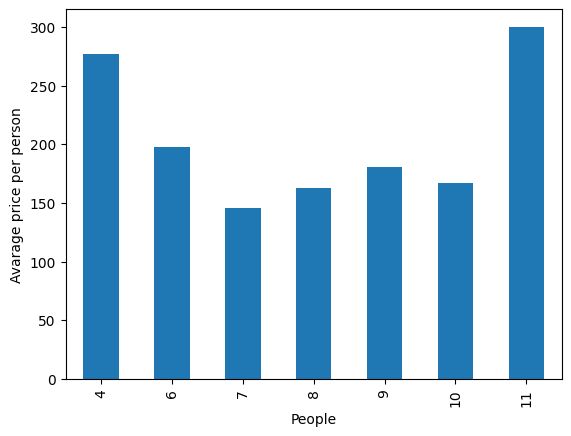

In [18]:
df['Price_per_person'] = df['Price'] / df['People']
temp = df.groupby('People')['Price_per_person'].mean()
temp.plot(kind='bar', ylabel='Avarage price per person')

Before we choose an yacht, we should have invited our friends, so let's choose which number of people will give us the most yachts to choose from

<Axes: ylabel='Number of offerts by number of people'>

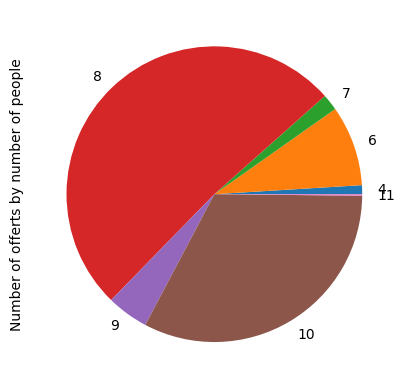

In [19]:
temp = df.groupby('People')['Name'].count()
temp.plot(kind='pie', ylabel='Number of offerts by number of people')

## Price per location

We have prepared our group so let's choose a localization

In [20]:
filtered_df = df[df.People == 8]
num = filtered_df.groupby('Location')['Link'].count()
num = num[num > 15]
filtered_df = filtered_df[filtered_df.Location.isin(num.index)]

<Axes: xlabel='Location', ylabel='Price'>

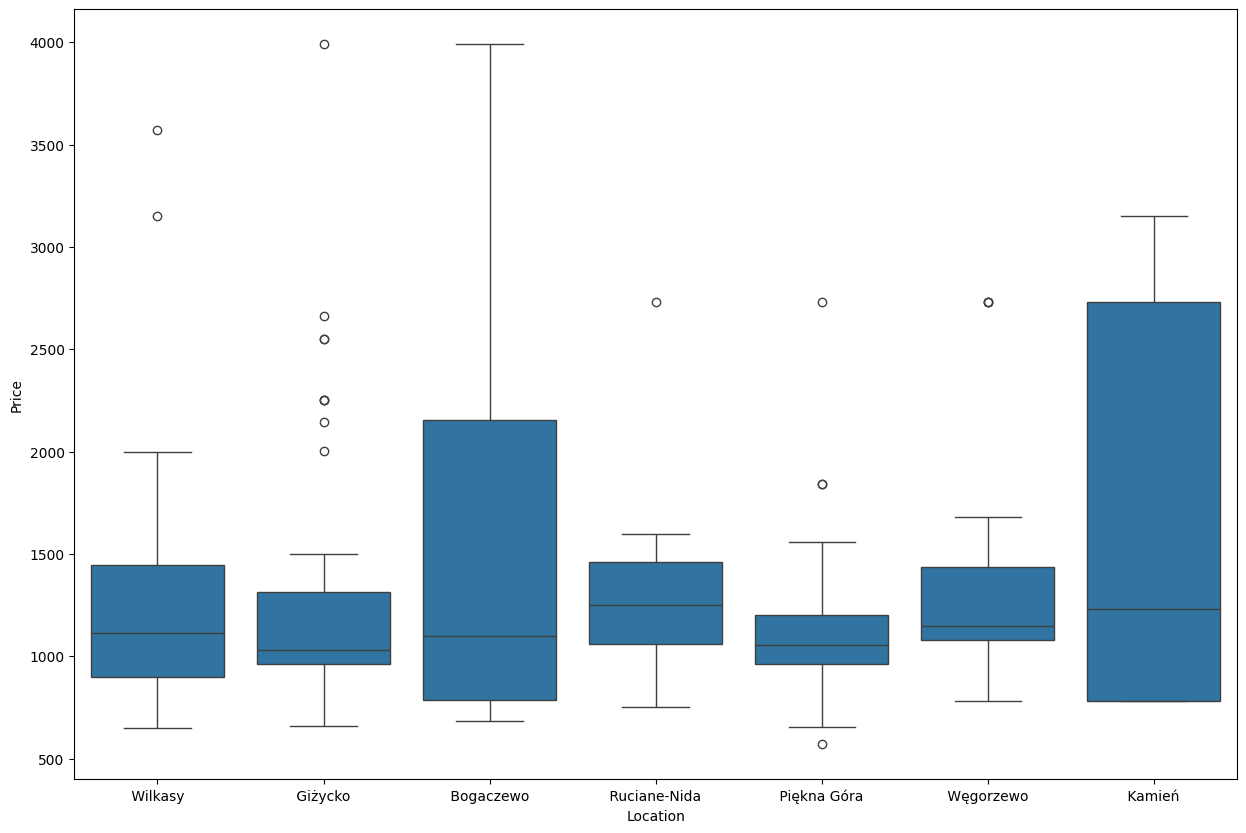

In [21]:
fig = plt.figure(figsize=(15, 10))
sns.boxplot(x = filtered_df['Location'], y = filtered_df['Price'])

## Let's find other correlations

<Axes: >

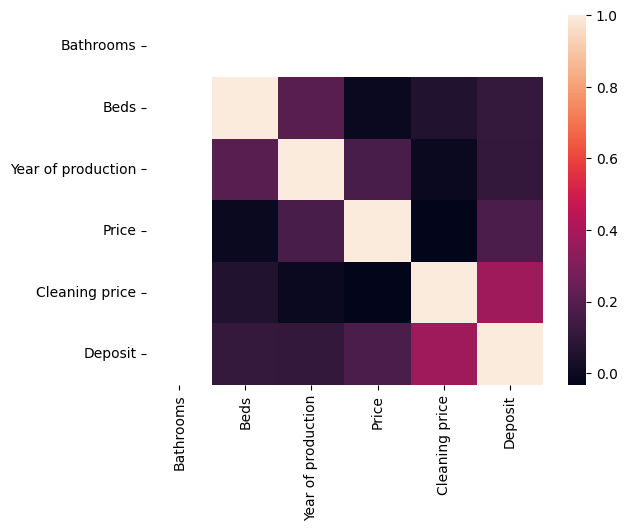

In [22]:
avgs = filtered_df[['Bathrooms','Beds', 'Year of production', 'Price', 'Cleaning price', 'Deposit']]
sns.heatmap(avgs.corr())

## Does year of production matter?

<Axes: xlabel='Year of production', ylabel='Price'>

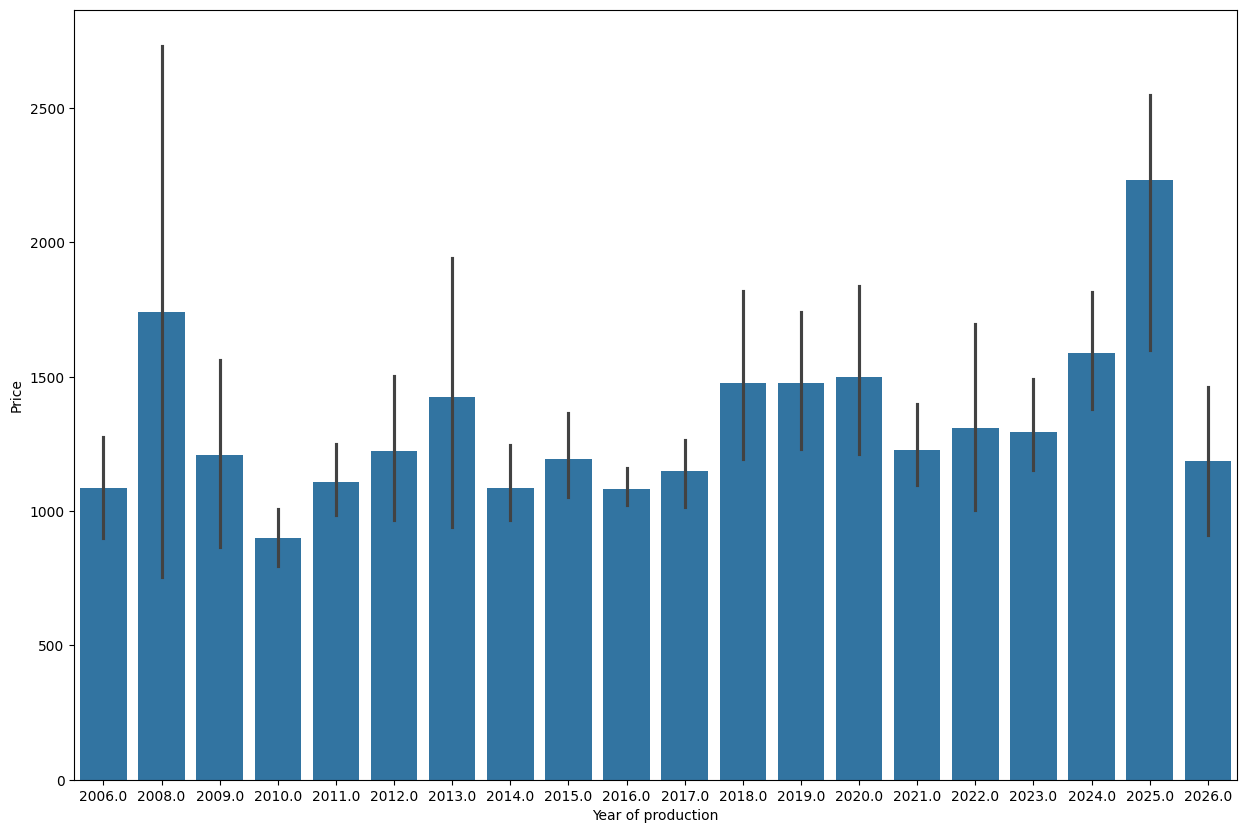

In [23]:
plt.figure(figsize=(15, 10))
sns.barplot(data=filtered_df, x='Year of production', y = 'Price')